### **Analisis Data Penjualan BMW Global (2018–2025)**


#### **Import Modul**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **Load Dataset**

In [3]:
path_dataset = '../dataset/bmw_global_sales_2018_2025.csv'
dataframe = pd.read_csv(path_dataset)
df = dataframe.copy()

##### **1. Menampilkan Preview Data**

In [4]:
# 5 Data Pertama
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,Jan,Europe,3 Series,7822.0,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280.0,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105.0,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420.0,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474.0,92300,782150200,0.035,19.12,3.5,1.0


##### **2. Melihat Jumlah Baris dan Kolom**

In [5]:
# Jumlah Data dan Kolom (Data, Kolom)
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]}')

Baris: 3092
Kolom: 11


| Kolom | Deskripsi | Satuan/Jenis |
|------|-----------|--------------|
| Year | Tahun terjadinya penjualan kendaraan | Tahun (2018-2025) |
| Month | Bulan terjadinya penjualan kendaraan | Bulan (1 = Januari, ..., 12 = Desember) |
| Region | Wilayah pemasaran kendaraan | Kategori: Europe, China, USA, RestOfWorld |
| Model | Tipe mobil BMW (misal: 3 Series, X5, i4, MINI, dll.) | Kategori |
| Units_Sold | Jumlah unit mobil yang berhasil terjual | Angka (unit) |
| Avg_Price_EUR | Harga rata-rata per unit dalam Euro | Mata uang (Euro) |
| Revenue_EUR | Total pendapatan dari penjualan (Units_Sold x Avg_Price_EUR) | Mata uang (Euro) |
| BEV_Share | Persentase penjualan mobil listrik (Battery Electric Vehicle) dari total penjualan mobil di wilayah tersebut | Persentase (skala 0-1, misal 0,25 = 25%) |
| Premium_Share | Persentase penjualan BMW di segmen premium dibanding total pasar premium di wilayah tersebut | Persentase (skala 0-1) |
| GDP_Growth | Pertumbuhan ekonomi regional (Produk Domestik Bruto) dalam persen | Persentase (misal 2,5 berarti 2,5%) |
| Fuel_Price_Index | Indeks harga bahan bakar relatif terhadap tahun dasar tertentu | Indeks (angka, misal 110 berarti 10% lebih mahal dari tahun dasar) |

#### **Exploratory Data Analysis (EDA)**

##### **3. Cek Tipe Data dan Key dari Data**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3092 entries, 0 to 3091
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3092 non-null   int64  
 1   Month             3092 non-null   object 
 2   Region            3086 non-null   object 
 3   Model             3092 non-null   object 
 4   Units_Sold        3086 non-null   float64
 5   Avg_Price_EUR     3092 non-null   int64  
 6   Revenue_EUR       3092 non-null   int64  
 7   BEV_Share         3092 non-null   float64
 8   Premium_Share     3092 non-null   float64
 9   GDP_Growth        3092 non-null   float64
 10  Fuel_Price_Index  3092 non-null   float64
dtypes: float64(5), int64(3), object(3)
memory usage: 265.8+ KB


In [7]:
df.describe()

,Year,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3092.000000,3086.000000,3092.000000,3.092000e+03,3092.000000,3092.000000,3092.000000,3092.000000
mean,2021.502911,7980.127673,63834.257762,5.248797e+08,0.107649,14.661362,3.055640,1.176336
std,2.293914,3178.601613,14671.303216,4.943812e+08,0.058171,5.330418,1.017302,0.118294
min,2018.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.000000,5215.750000,49979.000000,3.125504e+08,0.057000,14.050000,2.370000,1.080000
50%,2022.000000,7982.500000,63449.500000,4.812335e+08,0.108000,16.260000,3.050000,1.180000
75%,2024.000000,10527.750000,73006.750000,6.711959e+08,0.158000,18.930000,3.850000,1.270000
max,2025.000000,15914.000000,93994.000000,1.433482e+10,0.223000,20.970000,5.820000,1.410000


##### **4. Melihat Duplikasi Data**

Terdapat 20 Duplikat Data

In [8]:
print(f'Data Duplikat: {df.duplicated().sum()}\nTotal Data: {df.shape}')
print(df.duplicated().value_counts())
print(df[df.duplicated()].index)

Data Duplikat: 20
Total Data: (3092, 11)
False    3072
True       20
Name: count, dtype: int64
Index([3072, 3073, 3074, 3075, 3076, 3077, 3078, 3079, 3080, 3081, 3082, 3083,
       3084, 3085, 3086, 3087, 3088, 3089, 3090, 3091],
      dtype='int64')


Karena Terdapat 20 duplikat data sama, sebaiknya melakukan drop pada tabel yang duplikat. kenapa? Jika data duplikat tidak dihapus, analisis seperti tren penjualan, distribusi kategori, atau korelasi antar variabel dapat menghasilkan kesimpulan yang salah karena beberapa data dihitung lebih dari sekali.

In [9]:
# hapus kolom duplikat
df = df.drop_duplicates()
print(df)

      Year Month       Region     Model  Units_Sold  Avg_Price_EUR  \
0     2018   Jan       Europe  3 Series      7822.0          47482   
1     2018     1       Europe  5 Series     10280.0          61685   
2     2018     1       Europe        X3      3105.0          58433   
3     2018     1       Europe        X5      7420.0          67955   
4     2018     1       Europe        X7      8474.0          92300   
...    ...   ...          ...       ...         ...            ...   
3067  2025    12  RestOfWorld        X5      9281.0          68198   
3068  2025    12  RestOfWorld        X7     12785.0          91839   
3069  2025    12  RestOfWorld        i4      4906.0          63437   
3070  2025    12  RestOfWorld        iX      7871.0          73867   
3071  2025    12  RestOfWorld      MINI      6732.0          41811   

      Revenue_EUR  BEV_Share  Premium_Share  GDP_Growth  Fuel_Price_Index  
0       371404204      0.011          19.12        3.50              1.00  
1      

##### **5. Melihat Missing Values Pada Data**

In [10]:
print('Missing values per kolom:')
print(df.isnull().sum())

Missing values per kolom:
Year                0
Month               0
Region              6
Model               0
Units_Sold          6
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64


In [11]:
df[df['Region'].isnull()].head(6)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
298,2018,10,NaN,X3,4788.0,59180,283353840,0.020,19.19,5.28,0.92
818,2020,2,NaN,X3,6698.0,57572,385617256,0.069,18.43,3.08,1.13
1089,2020,11,NaN,5 Series,7485.0,62007,464122395,0.083,18.58,1.24,1.09
1394,2021,8,NaN,X3,11853.0,57869,685921257,0.096,15.50,4.50,1.18
2063,2023,5,NaN,MINI,8733.0,43363,378689079,0.144,20.30,4.47,1.24
2557,2024,8,NaN,i4,11827.0,64196,759246092,0.173,6.29,1.84,1.35


In [12]:
df[df['Units_Sold'].isnull()].head(6)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
496,2019,4,USA,3 Series,NaN,48938,373054374,0.046,19.64,2.98,1.07
640,2019,9,Europe,3 Series,NaN,49384,557347824,0.016,14.35,3.91,1.09
1039,2020,9,China,MINI,NaN,40757,344844977,0.079,20.13,3.71,1.10
1462,2021,10,USA,iX,NaN,75048,741023952,0.091,17.59,1.70,1.14
2423,2024,4,USA,MINI,NaN,43504,349119600,0.181,20.97,2.92,1.31
2847,2025,5,RestOfWorld,MINI,NaN,43845,498868410,0.184,5.29,2.31,1.38


Hapus baris dengan Units_Sold kosong (karena hanya 6 baris, tidak memengaruhi tren). Untuk Region, bisa diisi dengan 'Unknown' agar tidak hilang, karena tidak digunakan langsung dalam analisis musiman global

In [13]:
# Hapus NaN Units_Sold
df = df.dropna(subset=['Units_Sold'])
# Untuk region tidak apa diganti unknown karena kita tidak spesifik menggunakan tren per region
df['Region'] = df['Region'].fillna('Unknown')
# cek datafr
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

##### **6. Melihat Konsistensi Penulisan Pada Data**

In [14]:
for kolom in df.columns:
  print(kolom)
  print(df[kolom].unique(), "\n")

Year
[2018 2019 2020 2021 2022 2023 2024 2025] 

Month
['Jan' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12'] 

Region
['Europe' 'China' 'USA' 'RestOfWorld' 'Unknown'] 

Model
['3 Series' '5 Series' 'X3' 'X5' 'X7' 'i4' 'iX' 'MINI'] 

Units_Sold
[ 7822. 10280.  3105. ...  4906.  7871.  6732.] 

Avg_Price_EUR
[47482 61685 58433 ... 63437 73867 41811] 

Revenue_EUR
[371404204 634121800 181434465 ... 311221922 581407157 281471652] 

BEV_Share
[ 0.011  0.019  0.022  0.021  0.035  0.016  0.013  0.015  0.014  0.017
  0.02   0.009  0.007  0.031  0.01   0.004  0.026  0.029 -0.     0.012
  0.018  0.023  0.03   0.028  0.008  0.034  0.003  0.045  0.025  0.032
  0.033  0.039  0.027  0.024  0.04   0.002  0.041  0.052  0.005  0.006
 -0.001  0.001  0.036 -0.015 -0.002  0.044 -0.005  0.038 -0.003  0.043
 -0.007  0.037  0.046  0.056  0.058  0.051  0.055  0.042  0.048  0.05
  0.054  0.069  0.047  0.062  0.049  0.057  0.053  0.06   0.063  0.064
  0.067  0.061  0.07   0.066  0.071  0.059  0.065  0.084 

In [15]:
df['Month'] = df['Month'].replace('Jan', '1')
df['Month'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'],
      dtype=object)

##### **7. Konversi Tipe Data**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3066 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3066 non-null   int64  
 1   Month             3066 non-null   object 
 2   Region            3066 non-null   object 
 3   Model             3066 non-null   object 
 4   Units_Sold        3066 non-null   float64
 5   Avg_Price_EUR     3066 non-null   int64  
 6   Revenue_EUR       3066 non-null   int64  
 7   BEV_Share         3066 non-null   float64
 8   Premium_Share     3066 non-null   float64
 9   GDP_Growth        3066 non-null   float64
 10  Fuel_Price_Index  3066 non-null   float64
dtypes: float64(5), int64(3), object(3)
memory usage: 287.4+ KB


In [17]:
for kolom in df.columns:
  print(kolom)
  print(df[kolom].unique(), "\n")

Year
[2018 2019 2020 2021 2022 2023 2024 2025] 

Month
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12'] 

Region
['Europe' 'China' 'USA' 'RestOfWorld' 'Unknown'] 

Model
['3 Series' '5 Series' 'X3' 'X5' 'X7' 'i4' 'iX' 'MINI'] 

Units_Sold
[ 7822. 10280.  3105. ...  4906.  7871.  6732.] 

Avg_Price_EUR
[47482 61685 58433 ... 63437 73867 41811] 

Revenue_EUR
[371404204 634121800 181434465 ... 311221922 581407157 281471652] 

BEV_Share
[ 0.011  0.019  0.022  0.021  0.035  0.016  0.013  0.015  0.014  0.017
  0.02   0.009  0.007  0.031  0.01   0.004  0.026  0.029 -0.     0.012
  0.018  0.023  0.03   0.028  0.008  0.034  0.003  0.045  0.025  0.032
  0.033  0.039  0.027  0.024  0.04   0.002  0.041  0.052  0.005  0.006
 -0.001  0.001  0.036 -0.015 -0.002  0.044 -0.005  0.038 -0.003  0.043
 -0.007  0.037  0.046  0.056  0.058  0.051  0.055  0.042  0.048  0.05
  0.054  0.069  0.047  0.062  0.049  0.057  0.053  0.06   0.063  0.064
  0.067  0.061  0.07   0.066  0.071  0.059  0.065  0.084  0.101

Kolom Month saat ini masih bertipe string ('1' sampai '12'). Kita perlu mengubahnya menjadi integer dan membuat kolom tanggal untuk memudahkan plotting (visualisasi) dan agregasi(penggabungan data/merangkum).

In [18]:
# Ubah Month menjadi integer
df['Month'] = df['Month'].astype(int)

# Buat kolom Date (awal bulan)
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Urutkan berdasarkan tanggal
df = df.sort_values('Date').reset_index(drop=True)

df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date
0,2018,1,Europe,3 Series,7822.0,47482,371404204,0.011,19.12,3.50,1.00,2018-01-01
1,2018,1,RestOfWorld,MINI,9570.0,42278,404600460,0.000,6.28,4.18,0.97,2018-01-01
2,2018,1,RestOfWorld,iX,9412.0,74757,703612884,0.021,6.28,4.18,0.97,2018-01-01
3,2018,1,RestOfWorld,i4,3194.0,65790,210133260,0.010,6.28,4.18,0.97,2018-01-01
4,2018,1,RestOfWorld,X7,7252.0,93762,679962024,0.018,6.28,4.18,0.97,2018-01-01


Penjelasan:
- astype(int) mengubah string angka menjadi integer.
- pd.to_datetime membuat objek datetime yang bisa diurutkan dan di-resample.
- Pengurutan penting untuk analisis deret waktu.

##### **8. Agregasi / Menggabungkan Data Menjadi Satu Nilai**
Menjumlahkan Units_Sold untuk setiap bulan (semua region dan model) untuk mendapatkan total penjualan global per bulan.

In [19]:
monthly_sales = df.groupby(['Year', 'Month'])['Units_Sold'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str) + '-01')
monthly_sales = monthly_sales.sort_values('Date').reset_index(drop=True)

print(monthly_sales.head())

   Year  Month  Units_Sold       Date
0  2018      1    230195.0 2018-01-01
1  2018      2    201033.0 2018-02-01
2  2018      3    250912.0 2018-03-01
3  2018      4    249552.0 2018-04-01
4  2018      5    218362.0 2018-05-01


Data per baris (per model/region) digabungkan menjadi satu baris per bulan.

In [20]:
monthly_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Year        96 non-null     int64         
 1   Month       96 non-null     int64         
 2   Units_Sold  96 non-null     float64       
 3   Date        96 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 3.1 KB


In [21]:
monthly_sales.head()

,Year,Month,Units_Sold,Date
0,2018,1,230195.0,2018-01-01
1,2018,2,201033.0,2018-02-01
2,2018,3,250912.0,2018-03-01
3,2018,4,249552.0,2018-04-01
4,2018,5,218362.0,2018-05-01


##### **9. Visualisasi Deret Waktu Bulanan**

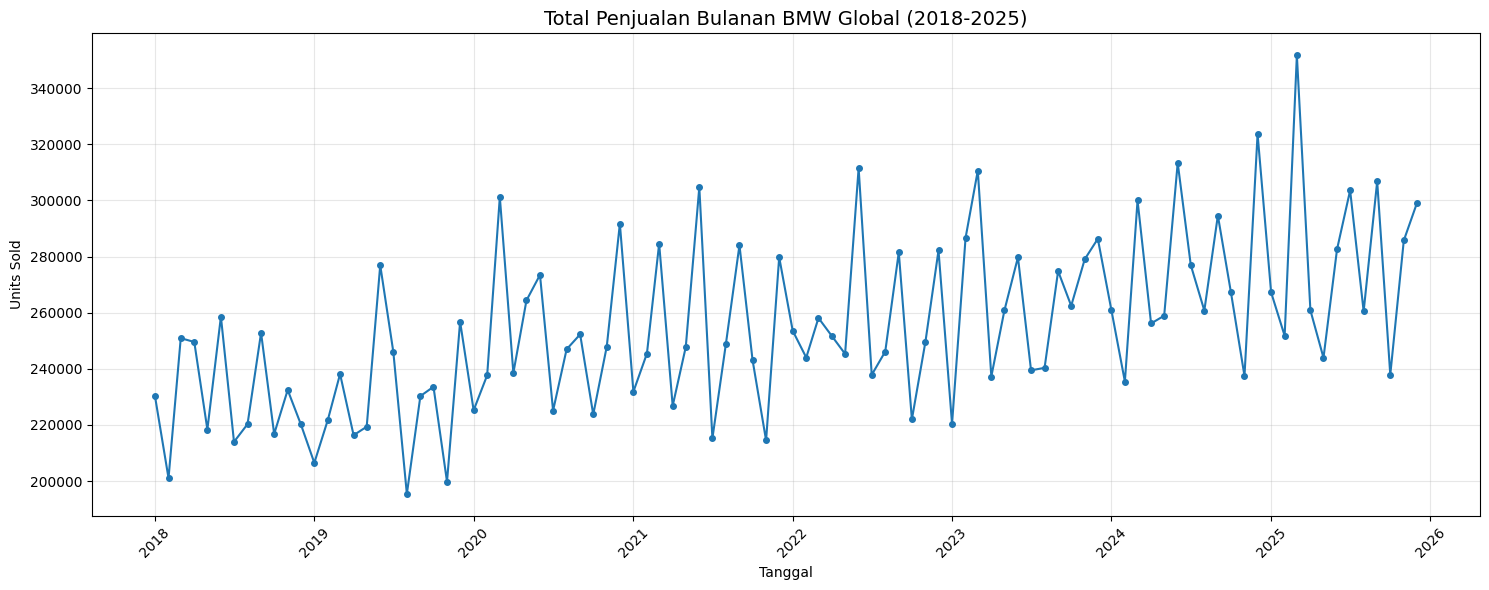

In [22]:
plt.figure(figsize=(15,6))
plt.plot(monthly_sales['Date'], monthly_sales['Units_Sold'], marker='o', linestyle='-', markersize=4)
plt.title('Total Penjualan Bulanan BMW Global (2018-2025)', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Units Sold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **10. Visualisasi Rata-rata Penjualan Bulanan**

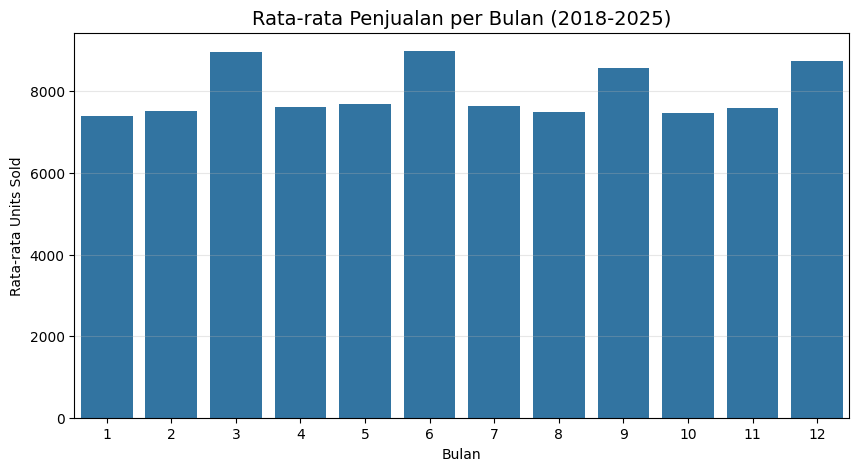

    Bulan  Rata2_Penjualan
0       1      7405.792969
1       2      7514.968750
2       3      8965.953125
3       4      7626.086614
4       5      7681.525490
5       6      8987.496094
6       7      7648.558594
7       8      7497.222656
8       9      8571.303150
9      10      7477.101961
10     11      7603.207031
11     12      8748.718750


In [23]:
monthly_avg = df.groupby('Month')['Units_Sold'].mean().reset_index()
monthly_avg.columns = ['Bulan', 'Rata2_Penjualan']

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_avg, x='Bulan', y='Rata2_Penjualan')
plt.title('Rata-rata Penjualan per Bulan (2018-2025)', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Units Sold')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(monthly_avg)

In [ ]:
# Mencari data dengan rata-rata penjualan tertinggi
bulan_tertinggi = monthly_avg.loc[monthly_avg['Rata2_Penjualan'].idxmax()]

# Mencari data dengan rata-rata penjualan terendah
bulan_terendah = monthly_avg.loc[monthly_avg['Rata2_Penjualan'].idxmin()]

print("--- Hasil Analisis Nilai Ekstrem Penjualan Bulanan ---")
print(f"Rata-rata Penjualan TERTINGGI terjadi pada Bulan ke-{int(bulan_tertinggi['Bulan'])}")
print(f"Total Rata-rata: {bulan_tertinggi['Rata2_Penjualan']:.2f} unit\n")

print(f"Rata-rata Penjualan TERENDAH terjadi pada Bulan ke-{int(bulan_terendah['Bulan'])}")
print(f"Total Rata-rata: {bulan_terendah['Rata2_Penjualan']:.2f} unit")

--- Hasil Analisis Nilai Ekstrem Penjualan Bulanan ---
Rata-rata Penjualan TERTINGGI terjadi pada Bulan ke-6
Total Rata-rata: 8987.50 unit

Rata-rata Penjualan TERENDAH terjadi pada Bulan ke-1
Total Rata-rata: 7405.79 unit


##### **12. Analisis Hasil Program**

##### **Analisis Tren Penjualan Bulanan:**
Berdasarkan proses agregasi/penggabungan data rata-rata penjualan bulanan yang telah dieksekusi, kita dapat melihat adanya pola musiman yang cukup jelas pada perilaku pembelian konsumen BMW secara global. Rata-rata penjualan menyentuh angka tertingginya pada bulan ke-6 (Juni), dengan pencapaian sekitar 8.987 unit kendaraan. Lonjakan signifikan pada pertengahan tahun ini kemungkinan besar didorong oleh tren liburan musim panas di berbagai wilayah pasar utama, di mana mobilitas masyarakat meningkat pesat. Selain itu, bulan Juni sering kali menjadi momentum bagi pabrikan otomotif untuk memperkenalkan model penyegaran (facelift) atau mengadakan kampanye diskon pertengahan tahun yang agresif.

Sebaliknya, titik terendah dari rata-rata penjualan global terjadi pada bulan pertama (Januari), dengan jumlah penjualan berada di kisaran 7.405 unit. Penurunan tajam di awal tahun ini merupakan fenomena yang sangat wajar dan dapat diprediksi dalam siklus industri ritel maupun otomotif. Hal ini terjadi karena konsumen cenderung menahan pengeluaran modal besar setelah tingginya tingkat konsumsi dan daya beli yang terkuras pada masa liburan akhir tahun di bulan Desember (yang terbukti memiliki angka penjualan tinggi sekitar 8.748 unit). Secara keseluruhan, analisis ini mengindikasikan bahwa paruh pertama tahun berjalan relatif lambat, sebelum akhirnya memuncak pada pertengahan tahun, dan kembali menunjukkan kekuatan pada akhir tahun dan kuartal pertama (seperti lonjakan di bulan Maret).